# Calculating NMR Spectra with SimpCalc

This tutorial demonstrates how to use `SimpCalc` to design and run NMR simulations using SIMPSON. We will cover defining spin systems, setting up the calculator, using different pulse sequences, and handling simulation outputs.

## 1. Defining the Spin System

The spin system defines the nuclei, their chemical shifts, and couplings. You can define this using a SIMPSON-formatted string or use `soprano` objects if you have them from DFT calculations.

In [1]:
from __future__ import annotations

import shutil

import matplotlib.pyplot as plt

from simpyson.calculator import SimpCalc

# Check if SIMPSON is installed
SIMPSON_INSTALLED = shutil.which('simpson') is not None
if not SIMPSON_INSTALLED:
    print("WARNING: 'simpson' executable not found in PATH. You can generate input files but cannot run simulations directly.")
else:
    print("SIMPSON detected. Ready to run simulations.")

SIMPSON detected. Ready to run simulations.


In [2]:
# Define a simple 2-spin system
spinsys_str = """
channels 1H
nuclei 1H 1H
shift 1 2.5p 0 0 0 0 0
shift 2 7.0p 0 0 0 0 0
"""

## 2. Setting up the Calculator

`SimpCalc` is the main interface. You initialize it with your spin system and simulation parameters.

**Note**: SimpCalc requires several parameters to be explicitly set, even if standard defaults are desired.

In [15]:
sim = SimpCalc(
    spinsys=spinsys_str,
    proton_frequency='400MHz',
    sw=2000,          # Spectral width in Hz
    np=4096,          # Number of points
    variable_ref=0,   # Center frequency
    # Creating standard static simulation parameters
    spin_rate='10e3', # MAS rate in Hz
    start_operator="I1x",
    detect_operator="I1p",
    method="direct",
    crystal_file="rep100", # Powder averaging
    gamma_angles=10,
    verbose=0
)

# Save file
sim.save('my_simulation.in')

## 3. Pulse Sequences

`SimpCalc` supports various pulse sequences. The default is `'no_pulse'` (just acquire). You can specify others like `'pulse90'` or `'cpmas'`.

### 3.1 Standard Pulse-Acquire (Pulse90)
This uses a simple 90-degree pulse before acquisition.

In [38]:
from simpyson.templates import Pulse90

pulse90 = Pulse90()

spinsys_13C = """
channels 13C
nuclei 13C 13C
shift 1 50p 0 0 0 0 0
shift 2 20p 0 0 0 0 0
"""

sim_90 = SimpCalc(
    spinsys=spinsys_13C,
    proton_frequency='400e6',
    sw=20000,
    np=4096,
    # Standard Parameters
    spin_rate='10e3', # MAS rate in Hz
    start_operator="Inz", # Start with z, then pulse90 flips it
    detect_operator="Inp",
    method="direct",
    crystal_file="rep100",
    gamma_angles=10,
    verbose=0,
    pulse_sequence=pulse90,
    lb=10,                     # Add line broadening
    zerofill=4096              # Add zerofill
)

## 4. Running the Simulation

If `simpson` is available, you can run the simulation explicitly. The `run` method returns a `Simpy` object containing the result.

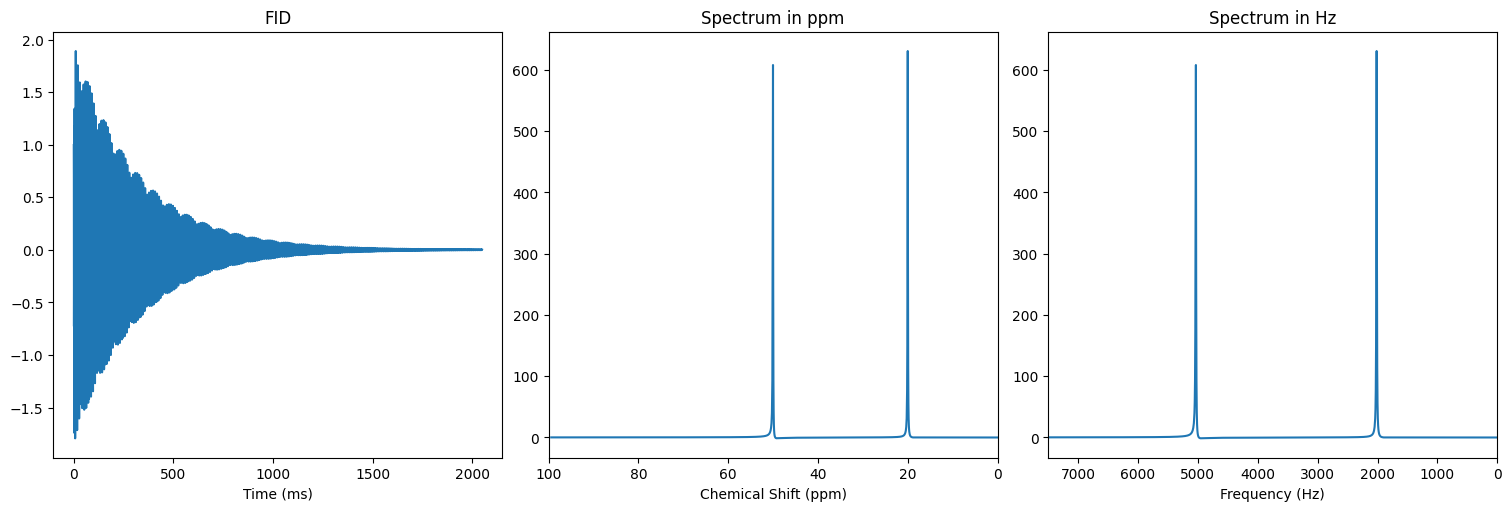

In [43]:
output = sim_90.run(read_output=True)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,5), constrained_layout=True)
ax[0].plot(output.fid['time'], output.fid['real'])
ax[0].set_title('FID')
ax[0].set_xlabel('Time (ms)')
ax[1].plot(output.spe['ppm'], output.spe['real'])
ax[1].set_title('Spectrum in ppm')
ax[1].set_xlim(100, 0)
ax[1].set_xlabel('Chemical Shift (ppm)')
ax[2].plot(output.spe['hz'], output.spe['real'])
ax[2].set_xlim(7500, 0)
ax[2].set_title('Spectrum in Hz')
ax[2].set_xlabel('Frequency (Hz)')
plt.show()

## 5. Advanced: Cross Polarization (CPMAS)

CPMAS requires more parameters like spin rate and RF fields. Simpyson provides a template for this.

In [56]:
from simpyson.templates import CPMAS

# Example spin system for CP (H -> C)
cp_spinsys = """
channels 1H 13C
nuclei 1H 13C 13C
shift 1 2.0p 0 0 0 0 0
shift 2 10p 0 0 0 0 0
shift 3 15p 0 0 0 0 0
dipole 1 2 -2000 0 0 0
dipole 1 3 -200 0 0 0
"""

cp_seq = CPMAS()
# cp_seq.parameters['pcp'] = 2000 # Contact time in us

sim_cp = SimpCalc(
    spinsys=cp_spinsys,
    proton_frequency='400e6',
    sw=10000,
    spin_rate=10000,   # 10 kHz MAS
    # Standard Parameters
    start_operator="I1x",
    detect_operator="I2p+I3p", # Detect on 13C (channel 2)
    method="direct",
    crystal_file="rep100",
    gamma_angles=10,
    verbose=0,
    np=4096,
    pulse_sequence=cp_seq
)

if SIMPSON_INSTALLED:
    try:
        res_cp = sim_cp.run()
        plt.figure(figsize=(10, 5))
        plt.plot(res_cp.ppm['ppm'], res_cp.ppm['real'])
        plt.title("CPMAS Simulation")
        plt.show()
    except Exception as e:
        print(f"CPMAS Simulation failed: {e}")
else:
    print("Generated CPMAS input file:")
    # print(sim_cp.generate_input()) # Pseudocode to show generated string logic

CPMAS Simulation failed: Command '['/usr/local/bin/simpson', '/tmp/tmpq1bdumnv.in']' returned non-zero exit status 1.


In [57]:
sim_cp.print()

spinsys {

channels 1H 13C
nuclei 1H 13C 13C
shift 1 2.0p 0 0 0 0 0
shift 2 10p 0 0 0 0 0
shift 3 15p 0 0 0 0 0
dipole 1 2 -2000 0 0 0
dipole 1 3 -200 0 0 0

}

par {
   crystal_file         rep100
   detect_operator      I2p+I3p
   gamma_angles         10
   method               direct
   np                   4096
   proton_frequency     400e6
   spin_rate            10000
   start_operator       I1x
   sw                   10000
   verbose              0
   variable dw              1e6/spin_rate/gamma_angles
   variable p1H             5.0
   variable pcp             1000
   variable ph1H            y
   variable phCcp           0
   variable phHcp           0
   variable pl1H            50000
   variable plCcp           69000
   variable plHcp           70000
}


proc pulseq {} {
    global par
    reset
    pulse $par(p1H) $par(pl1H) $par(ph1H) 0 0
    pulse $par(pcp) $par(plHcp) $par(phHcp) $par(plCcp) $par(phCcp)
    turnoff dipole_1_2 jcoupling_1_2
    acq_block { 
        delay